In [1]:
import polars as pl
from pathlib import Path
import sys
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

ROOT_DIR = Path().resolve().parent
DATA_DIR = ROOT_DIR / "data" / "processed"
sys.path.append(str(Path().resolve().parent))

from src.config import CONFIG, CAT_CUSTOM
import src.tools as ts

import gc
gc.collect()

folder = Path(DATA_DIR)
files = list(folder.glob('food_transforme_*.parquet'))
df = ts.load_data(files)

print('Raw size', df.shape)

100%|██████████| 4/4 [00:00<00:00,  5.84it/s]

Raw size (2843268, 14)


In [2]:
df.describe()

statistic,nutriscore_grade,nutriscore_score,product_name,categories_tags,food_groups_tags,energy-kcal,energy-kj,fat,saturated-fat,sugars,proteins,salt,fiber,fruits-vegetables-nuts
str,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""2843200""",1.197713e6,"""2826196""",1.487774e6,2.843225e6,2.754477e6,384832.0,2.792154e6,2.605763e6,2.648952e6,2.775078e6,2.403728e6,1.354987e6,16288.0
"""null_count""","""68""",1.645555e6,"""17072""",1.355494e6,43.0,88791.0,2.458436e6,51114.0,237505.0,194316.0,68190.0,439540.0,1.488281e6,2.82698e6
"""mean""",null,11.283242,null,null,null,inf,inf,inf,inf,inf,inf,inf,inf,40.75763
"""std""",null,10.260182,null,null,null,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.72849
"""min""","""a""",-17.0,""" 18 marrons glacés""",null,null,-8.4467e18,0.0,0.0,0.0,-1.2,-3.57,0.0,-6.7,0.0
"""25%""",null,3.0,null,null,null,100.0,373.0,0.2,0.1,0.62,1.5,0.1,0.0,5.0
"""50%""",null,11.0,null,null,null,235.294113,863.0,2.9,1.8,3.57,6.0,0.7,1.6,44.0
"""75%""",null,19.0,null,null,null,386.0,1542.0,12.0,6.666667,15.0,13.0,1.8,3.6,64.5
"""max""","""unknown""",55.0,"""𰻞𰻞麺""",null,null,inf,inf,inf,inf,inf,inf,inf,inf,250.0


### A. Valeurs manquantes

#### nettoyage strict

In [3]:
nutri = CONFIG['selected_nutrient']

In [4]:
# NULL : drop row if all nutrients = nulls
df = ts.clean(df, nutri)
# NULL : drop score = null 
df = df.drop_nulls(subset=['nutriscore_score'])
print('Size without null : ', df.shape)
n = df.shape[0]

Size without null :  (1190906, 14)


#### remplacer les restantes par 0

In [5]:
df = df.with_columns([
    pl.col(col).fill_null(0) for col in nutri
])

#### kcal = 0
utiliser kj pour compléter kcal - 1 kcal = 4.184 kJ

In [14]:
df.filter(
    (pl.col('energy-kcal') == 0) & (pl.col('energy-kj') != 0)
    ).head(2)

nutriscore_grade,nutriscore_score,product_name,categories_tags,food_groups_tags,energy-kcal,energy-kj,fat,saturated-fat,sugars,proteins,salt,fiber,fruits-vegetables-nuts,energy-kj/4.184,energy-kcal-custom,sum_nutri
str,i32,str,list[str],list[str],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""a""",0,"""Hot Hafer Schoko""","[""en:plant-based-foods-and-beverages"", ""en:plant-based-foods"", … ""en:rolled-oats""]","[""en:cereals-and-potatoes"", ""en:breakfast-cereals""]",0.0,1654.0,10.0,3.7,7.5,12.0,0.04,9.5,0.0,395.315488,395.315488,42.74
"""e""",29,"""Морени Stix с Шоколад""","[""en:snacks"", ""en:sweet-snacks"", … ""en:chocolate-coated-waffles""]","[""en:sugary-snacks"", ""en:biscuits-and-cakes""]",0.0,2155.0,26.5,14.5,44.0,5.7,0.5,3.4,0.0,515.057361,515.057361,94.6


In [15]:
df = df.with_columns(
    (pl.col("energy-kj") / 4.184).alias("energy-kj/4.184")
)

df = df.with_columns(
    pl.when(pl.col("energy-kcal") == 0)
    .then(pl.col("energy-kj/4.184"))
    .otherwise(pl.col("energy-kcal"))
    .alias("energy-kcal")
)

### B. La variance des données

In [16]:
df.describe()

statistic,nutriscore_grade,nutriscore_score,product_name,categories_tags,food_groups_tags,energy-kcal,energy-kj,fat,saturated-fat,sugars,proteins,salt,fiber,fruits-vegetables-nuts,energy-kj/4.184,energy-kcal-custom,sum_nutri
str,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""981935""",981935.0,"""975069""",981935.0,981928.0,981935.0,981935.0,981935.0,981935.0,981935.0,981935.0,981935.0,981935.0,981935.0,981935.0,981935.0,981935.0
"""null_count""","""0""",0.0,"""6866""",0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,10.754417,null,null,null,268.808929,304.955638,9.507982,5.128774,11.708105,8.292387,1.057177,1.457567,0.63155,72.886147,268.808929,37.783542
"""std""",null,10.087553,null,null,null,628.344355,2591.346507,14.710719,7.723782,17.617771,8.529099,1.986093,3.360234,6.631982,619.34668,628.344355,29.306557
"""min""","""a""",-17.0,""" 18 marrons glacés""",null,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",null,2.0,null,null,null,104.0,0.0,0.3,0.13,0.6,1.5,0.06,0.0,0.0,0.0,104.0,15.0
"""50%""",null,11.0,null,null,null,245.0,0.0,3.1,1.9,3.4,6.0,0.5,0.0,0.0,0.0,245.0,28.8
"""75%""",null,18.0,null,null,null,392.857147,185.0,13.2,7.1,14.0,12.0,1.3,1.6,0.0,44.216061,392.857147,55.519999
"""max""","""e""",55.0,"""🥜 roasted and salted""",null,null,593116.156788,2.481598e6,100.0,80.0,90.0,80.0,20.0,50.0,100.0,593116.156788,593116.156788,283.5775


In [9]:
df.select(pl.col(nutri)).var().unpivot().sort("value", descending=True)

variable,value
str,f64
"""sugars""",1.6587e39
"""fiber""",8.3970e33
"""energy-kcal""",5.9910e31
"""fat""",2.4265e13
"""saturated-fat""",2.4265e13
"""energy-kj""",8.5267e11
"""proteins""",8.5427e9
"""salt""",6.0470e6
"""fruits-vegetables-nuts""",36.548668


### C. Valeurs aberrantes

In [10]:
nutrient_limit = CONFIG['nutrient_limit']

df_outliers = ts.anomaly_counts(df, nutrient_limit)
print('Size data without outliers = ', n - df_outliers['total'].sum())
df_outliers

Size data without outliers =  978886


feature,too_low,too_high,total
str,i64,i64,i64
"""salt""",0,201271,201271
"""energy-kcal""",1,1888,1889
"""fat""",0,403,403
"""sugars""",1,5370,5371
"""proteins""",2,978,980
"""saturated-fat""",0,1408,1408
"""fiber""",1,696,697
"""fruits-vegetables-nuts""",0,1,1


#### Exemple du sel

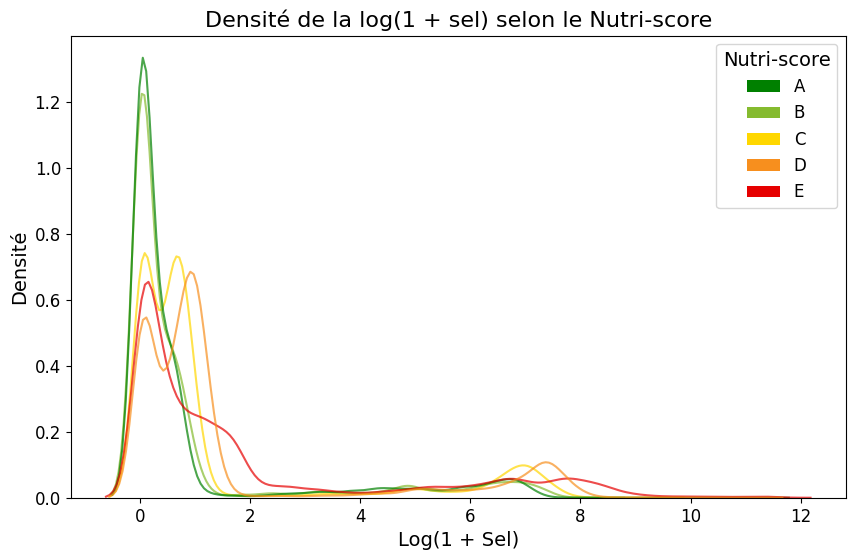

In [9]:
nutriscore_colors = {
        "A": "#008000",
        "B": "#85BB2F",
        "C": "#FFD700",
        "D": "#F78F1E",
        "E": "#E60000"
    }

df_plot = df.select(["salt", "nutriscore_grade"]).to_pandas()
df_plot["log_salt"] = np.log1p(df_plot["salt"])
df_plot['nutriscore_grade'] = df_plot['nutriscore_grade'].str.upper()

plt.figure(figsize=(10,6))
sns.kdeplot(data=df_plot, 
            x='log_salt', 
            hue='nutriscore_grade',
            common_norm=False,
            # fill=True,
            palette=nutriscore_colors, 
            alpha=0.7
            )

legend_elements = [
    Patch(facecolor=nutriscore_colors[k], label=k) for k in sorted(df_plot["nutriscore_grade"].unique())
    ]
plt.legend(handles=legend_elements, 
           title="Nutri-score", 
           title_fontsize=14,
           fontsize=12)

plt.title("Densité de la log(1 + sel) selon le Nutri-score", fontsize=16)
plt.xlabel("Log(1 + Sel)", fontsize=14)
plt.ylabel("Densité", fontsize=14)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12)
plt.show()

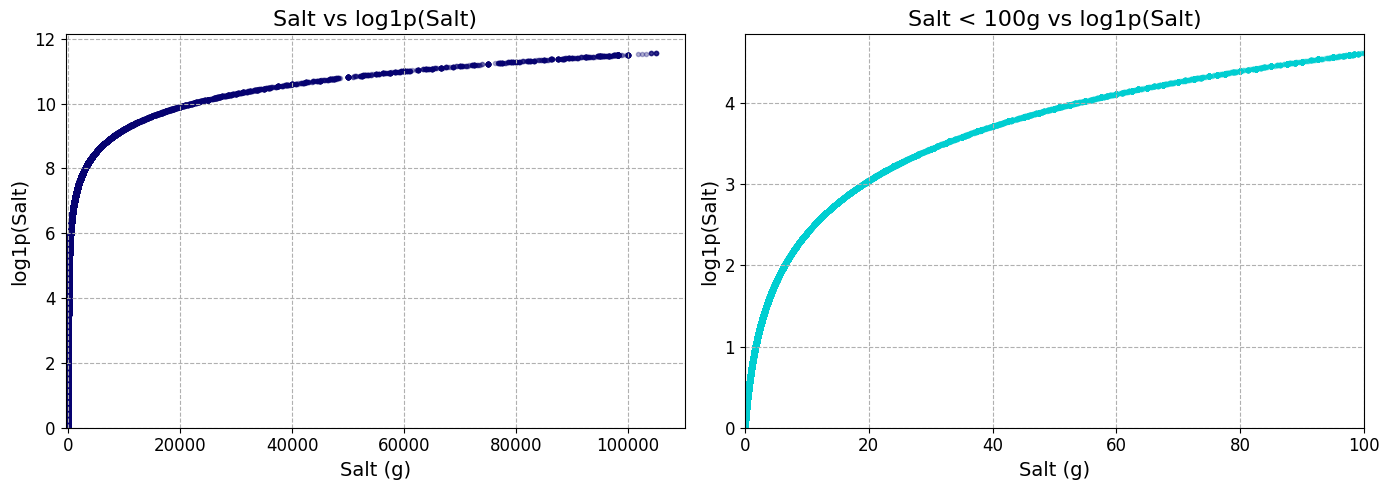

In [17]:
# Comportement de la fonction log
df_plot = df.to_pandas()
salt_values = df_plot["salt"].dropna().values
log_salt = np.log1p(salt_values)

def plot_salt_vs_log(ax, x, y, color, title, xlim=None, ylim=None):
    ax.scatter(x, y, alpha=0.3, c=color, marker='.')
    ax.set_xlabel("Salt (g)", fontsize=14)
    ax.set_ylabel("log1p(Salt)", fontsize=14)
    ax.set_title(title, fontsize=16)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.grid(True, linestyle='--')
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_salt_vs_log(
    axes[0],
    salt_values,
    log_salt,
    "#060270",
    "Salt vs log1p(Salt)",
    xlim=(-500, salt_values.max() * 1.05),
    ylim=(0, np.log1p(salt_values.max()) * 1.05)
)

mask = salt_values < 100
plot_salt_vs_log(
    axes[1],
    salt_values[mask],
    log_salt[mask],
    "#00CED1",
    "Salt < 100g vs log1p(Salt)",
    xlim=(0, 100),
    ylim=(0, np.log1p(100) * 1.05)
)

plt.tight_layout()
plt.show()

#### nettoyage strict

In [11]:
for col, (min_val, max_val) in nutrient_limit.items():
    df = df.filter(
        (pl.col(col) >= min_val) & (pl.col(col) <= max_val)
    )
    print('size after clip :', col, df.shape)

size after clip : salt (989635, 16)
size after clip : energy-kcal (989176, 16)
size after clip : fat (989008, 16)
size after clip : sugars (984415, 16)
size after clip : proteins (983817, 16)
size after clip : saturated-fat (982537, 16)
size after clip : fiber (981936, 16)
size after clip : fruits-vegetables-nuts (981935, 16)


#### + Amélioration possible : correction

In [10]:
# CORRECTION Douce

# KCAL & fat 1 auteur - facteur d'echelle
# def correct_energy(val):
#     if val is None:
#         return None
#     if val < 0 or val > 1500:
#         # essai de division si > 10kcal × 1000
#         for factor in [10, 100, 1000, 10000]:
#             candidate = val / factor
#             if 0 <= candidate <= 1500:
#                 return candidate
#         return None  # valeur incohérente
#     return val

# df = df.with_columns(
#     pl.col("energy-kcal").map_elements(correct_energy).alias("energy_kcal_cleaned")
# )

# Winsorisation - écrêtage : taille coupe :D
# df = df.with_columns([
#     pl.col("fat").clip(0, 100).alias("fat_clipped")
# ])

#### nutriments = 0 mais nutri-score > 2

In [23]:
c = ['fat',
    'saturated-fat',
    'sugars',
    'proteins',
    'salt',
    'fiber',	
    'fruits-vegetables-nuts']

df = df.with_columns(
    pl.sum_horizontal(*[pl.col(col) for col in c]).alias("sum_nutri")
)

df.filter(
    ((pl.col('sum_nutri') == 0) &
    (pl.col('nutriscore_score') > 2))
)

nutriscore_grade,nutriscore_score,product_name,categories_tags,food_groups_tags,energy-kcal,energy-kj,fat,saturated-fat,sugars,proteins,salt,fiber,fruits-vegetables-nuts,energy-kj/4.184,energy-kcal-custom,sum_nutri
str,i32,str,list[str],list[str],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""c""",4,"""Original Texture Fibre Laxativ…","[""en:plant-based-foods-and-beverages"", ""en:plant-based-foods""]",[],357.142853,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,357.142853,0.0
"""c""",4,"""Sparkling beverage""","[""en:beverages"", ""en:waters""]","[""en:beverages"", ""en:artificially-sweetened-beverages""]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""c""",4,"""Soft chewing gum""","[""en:snacks"", ""en:sweet-snacks"", ""en:confectioneries""]","[""en:sugary-snacks"", ""en:sweets""]",385.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,385.0,0.0
"""c""",4,"""Aqfs Lqenh Wldstr 1.62Oz Pet""","[""en:beverages-and-beverages-preparations"", ""en:beverages"", ""en:non-alcoholic-beverages""]","[""en:beverages"", ""en:artificially-sweetened-beverages""]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""c""",3,"""Trident gum spearmint winter s…","[""en:snacks"", ""en:sweet-snacks"", ""en:confectioneries""]","[""en:sugary-snacks"", ""en:sweets""]",294.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,294.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""c""",4,"""Indian tonic zero""","[""en:beverages"", ""en:carbonated-drinks"", … ""en:tonic-water""]","[""en:beverages"", ""en:artificially-sweetened-beverages""]",1.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.6,0.0
"""c""",4,"""Aloe vera""","[""en:plant-based-foods-and-beverages"", ""en:beverages"", … ""en:aloe-vera-drinks""]","[""en:beverages"", ""en:artificially-sweetened-beverages""]",3.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.107075,3.0,0.0
"""c""",3,"""Sugar free gum, strawberry""","[""en:snacks"", ""en:sweet-snacks"", ""en:confectioneries""]","[""en:sugary-snacks"", ""en:sweets""]",263.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,263.0,0.0


### D. Catégorie alimentaire

#### boissons

In [11]:
beverage_tag = CONFIG['beverage_tag']

df = df.with_columns([
    pl.col("food_groups_tags").map_elements(
        lambda cats: int(bool(set(cats) & beverage_tag)),
        return_dtype=pl.Int8
    ).alias("is_beverage")
])

In [12]:
c = 'is_beverage'
df.select(pl.col(c).value_counts()).unnest(c)

is_beverage,count
i8,u32
null,7
1,73957
0,906357


In [13]:
# drop beverage
df = df.filter(pl.col("is_beverage") == 0).drop("is_beverage")
print('Size without beverage : ', df.shape)

Size without beverage :  (906357, 13)


#### categorie englobante

In [14]:
c = 'food_groups_tags'
# les tags et leur répartition
df_exploded = df.select(
    pl.col(c).explode().alias('tag')
)

ts.val_cnt(df_exploded, 'tag', save=True)

tag,count
str,u32
"""en:lean-fish""",1577
"""en:offals""",1653
"""en:potatoes""",3858
"""en:soups""",4202
"""en:eggs""",4218
…,…
"""en:milk-and-dairy-products""",108239
"""en:cereals-and-potatoes""",114384
"""en:fish-meat-eggs""",119451


In [14]:
# New cat creation
tag_to_category = {
    tag: category
    for category, tags in CAT_CUSTOM.items()
    for tag in tags
}

df = df.with_columns([
    pl.col("food_groups_tags").map_elements(
        lambda tag_list: list(
            {tag_to_category[tag] for tag in tag_list 
             if tag in tag_to_category}
        ),
        return_dtype=pl.List(pl.String)
    ).alias("tags_custom")
])

In [15]:
ts.len_list(df, 'tags_custom')

tags_custom_len,count
u32,u32
0,152399
1,724378
2,29580


In [ ]:
# add None for same size list
df = df.with_columns([
    pl.when(pl.col("tags_custom").list.len() < 3)
      .then(
          pl.col("tags_custom").list.concat(
              [None] * 3)
              )
      .otherwise(pl.col("tags_custom"))
      .alias("tags_custom")
])

# extraction tag in columns feats
df = df.with_columns([
    pl.col("tags_custom").list.get(0).alias("tag_0"),  # Colonne pour l'index 0
    pl.col("tags_custom").list.get(1).alias("tag_1"),  # Colonne pour l'index 1
    pl.col("tags_custom").list.get(2).alias("tag_2")   # Colonne pour l'index 2
]).drop("tags_custom")

### E. Pays

In [ ]:
from src.tools import len_list
res = df.select(pl.col("countries_tags").value_counts()).unnest("countries_tags")

res=len_list(df, 'countries_tags')
res.filter(pl.col('count') > 1000)
# res/n*100
# res

In [ ]:
df.head()
df.filter(
    pl.col("country_1").is_not_null()
    )
df['country_0'].value_counts().sort(by='count')

In [ ]:
# list_pays = df["countries_tags"].explode().to_list()
# list_pays = set(list_pays)
# len(list_pays)
# list_pays